## **Ćwiczenia 9**
### *Rozwiązania zadań z przedmiotu Bioinformatyka 2 - A. Stanuch*

### **Zadanie 1**

In [ ]:
import numpy as np
import os

def parse_pdb_file(file_path):
    atom_data = []

    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                x = float(line[30:38].strip())
                y = float(line[38:46].strip())
                z = float(line[46:54].strip())
                
                atom_name = line[12:16].strip()
                res_seq = int(line[22:26].strip())
                chain_id = line[21].strip()
                
                atom_info = {
                    'x': x, 'y': y, 'z': z,
                    'name': atom_name,
                    'resid': res_seq,
                    'chain': chain_id
                }
                atom_data.append(atom_info)
    return atom_data

reference_pdb_path = './data/7qvb_A.pdb'
model_pdb_path     = './data/af2_pred.pdb'

reference_data = parse_pdb_file(reference_pdb_path)
model_data     = parse_pdb_file(model_pdb_path)

def filter_atom_data(atom_data, residue_numbers, atom_name):
    filtered_atom_data = []

    residue_set = set(residue_numbers)

    for atom in atom_data:
        if atom['resid'] in residue_set and atom['name'] == atom_name:
            filtered_atom_data.append(atom)

    return filtered_atom_data

atom_name_to_filter = 'CA'

filtered_reference_data = filter_atom_data(
    reference_data,
    list(range(5,159)),
    atom_name_to_filter
)

filtered_model_data = filter_atom_data(
    model_data,
    list(range(9,163)),
    atom_name_to_filter
)

def extract_xyz_positions(atom_data):
    coords = [[atom['x'], atom['y'], atom['z']] for atom in atom_data]
    return np.array(coords)

# użycie funkcji
filtered_reference_data_xyz = extract_xyz_positions(filtered_reference_data)
filtered_model_data_xyz     = extract_xyz_positions(filtered_model_data)

def align_coordinates(xyz_moving_A, xyz_fixed_B):
    centroid_A = np.mean(xyz_moving_A, axis=0)
    centroid_B = np.mean(xyz_fixed_B, axis=0)

    A_centered = xyz_moving_A - centroid_A
    B_centered = xyz_fixed_B - centroid_B

    H = A_centered.T @ B_centered
    U, S, Vt = np.linalg.svd(H)

    R = Vt.T @ U.T
    t = centroid_B - (centroid_A @ R.T)

    return R, t

# użycie funkcji
R, t = align_coordinates(
    filtered_model_data_xyz,
    filtered_reference_data_xyz
)

filtered_model_data_xyz_fitted = filtered_model_data_xyz @ R.T + t

def calculate_rmsd(xyz_A, xyz_B):      
    N = xyz_A.shape[0]
    diff = xyz_A - xyz_B
    sq_diff = np.sum(diff**2)
    rmsd = np.sqrt(sq_diff / N)

    return rmsd

print(
    f"RMSD pre fit:  {calculate_rmsd(filtered_reference_data_xyz, filtered_model_data_xyz):.3f} Å"
)
print(
    f"RMSD post fit: {calculate_rmsd(filtered_reference_data_xyz, filtered_model_data_xyz_fitted):.3f} Å"
)

RMSD pre fit:  61.054 Å
RMSD post fit: 1.358 Å


Przed RMSD jest wysokie, ponieważ struktury są przesunięte względem siebie. Po zastosowaniu algorytmu Kabsha struktury zostają nałożone na siebie tak, aby zminimalizować odległości między atomami. Dzięki temu RMSD pokazuje rzeczywiste różnice w kształcie białka.

### **Zadanie 2**

**Tabela do uzupełnienia**

| Model | TM-score | RMSD [Å] | Liczba dopasowanych reszt |
|------|----------|----------|----------------------------|
| AF2 | 0.9166 | 2.086 | 214 | 
| I-TASSER (exclude) | 0.3340 | 15.734 | 214 | 
| I-TASSER (100% ident) | 0.9937 | 0.455 | 214 | 


**Pytania do analizy**

1. Który model wykazuje najwyższą wartość TM-score?
    - I-TASSER (100% ident)
2. Czy kolejność modeli według TM-score jest zgodna z kolejnością według RMSD?
    - Tak
3. Które modele przekraczają próg TM-score = 0.5 i co to oznacza?
    - Dwa modele: AF2 i I-TASSER (100% ident). Oznacza to, że te modele mają poprawnie odwzorowany globalny zwój.
4. Jak obecność lub brak homologów wpływa na jakość predykcji struktury?
    - Brak homologów znacząco obniżył jakość predykcji.

### **Zadanie 3**

In [ ]:
import pymol
from pymol import cmd
import os

base = r"C:\dev\BioLogic\cwiczenia9\data"
ref_name = "7qvb_A.pdb"
files = ["af2_pred.pdb", "I-TASSER_exclude.pdb", "I-TASSER_100ident.pdb"]

r_r = list(range(5, 159)) + list(range(169, 223)) # reszty referencji
r_m = list(range(9, 163)) + list(range(173, 227)) # reszty modelu

cmd.delete("all")

ref_path = os.path.join(base, ref_name)
cmd.load(ref_path, "reference")


for f in files:
    path = os.path.join(base, f)
    obj = "current"
    cmd.load(path, obj)
    
    # lista reszt ktore faktycznie istnieja w pliku (zeby nie wywalało bledu)
    valid_r = []
    valid_m = [] 

    for i in range(len(r_m)):
        # stringi do selekcji w cmd.pair_fit
        sel_m = f"{obj} & resi {r_m[i]} & name CA" 
        sel_r = f"reference & resi {r_r[i]} & name CA & not alt B"
        
        if cmd.count_atoms(sel_m) == 1 and cmd.count_atoms(sel_r) == 1:
            valid_m.append(str(r_m[i]))
            valid_r.append(str(r_r[i]))

    if valid_m:
        s_m = "+".join(valid_m)
        s_r = "+".join(valid_r)
        cmd.pair_fit(f"{obj} & resi {s_m} & name CA", f"reference & resi {s_r} & name CA & not alt B")
    
    c1, c2, c4, c8 = 0, 0, 0, 0
    tot = len(r_m)

    for i in range(tot):
        sm = f"{obj} & resi {r_m[i]} & name CA"
        sr = f"reference & resi {r_r[i]} & name CA & not alt B"
        
        if cmd.count_atoms(sm) == 1 and cmd.count_atoms(sr) == 1:
            d = cmd.get_distance(sm, sr)
            if d <= 1.0: c1 += 1
            if d <= 2.0: c2 += 1
            if d <= 4.0: c4 += 1
            if d <= 8.0: c8 += 1

    p1 = (c1 / tot) * 100
    p2 = (c2 / tot) * 100
    p4 = (c4 / tot) * 100
    p8 = (c8 / tot) * 100
    ts = (p1 + p2 + p4 + p8) / 4

    print(f"Plik: {f}")
    print(f"P1: {p1:.2f} P2: {p2:.2f} P4: {p4:.2f} P8: {p8:.2f}")
    print(f"GDT_TS: {ts:.2f}")

    cmd.delete(obj)

Używałem tego skryptu wewnątrz PyMOLa ze względu na brak biblioteki *pymol-open-source* na Windowsa (a na Macu z jakiegoś powodu mi nie potrafił znaleźć biblioteki :/)

**Plik: af2_pred.pdb**
- P1: 33.17 P2: 86.54 P4: 99.04 P8: 99.04
- GDT_TS: 79.45

**Plik: I-TASSER_exclude.pdb**
- P1: 0.00 P2: 0.48 P4: 5.29 P8: 22.12
- GDT_TS: 6.97

**Plik: I-TASSER_100ident.pdb**
- P1: 98.08 P2: 99.52 P4: 100.00 P8: 100.00
- GDT_TS: 99.40

### **Zadanie 4**

**Tabela do uzupełnienia**

| Struktura | % reszt z 3D-1D score ≥ 0.1 |
|----------|-----------------------------|
| 7qvb_A.pdb (referencja) | 77.10% |
| af2_pred.pdb (AlphaFold2) | 71.91% |
| I-TASSER_exclude.pdb (I-TASSER) | 52.34% |

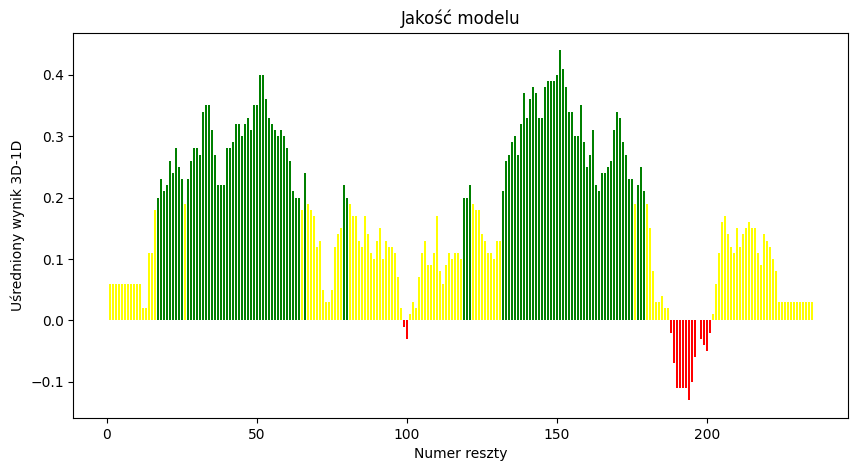

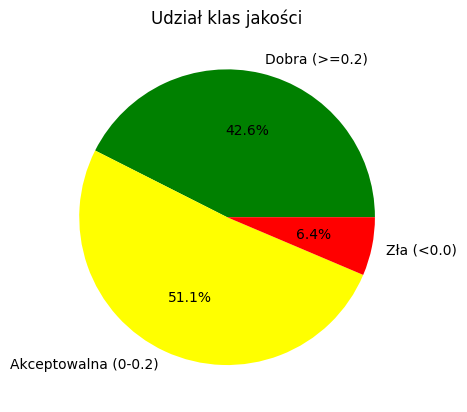

In [3]:
import matplotlib.pyplot as plt

file = open('data_zadanie4.txt', 'r')

numery_reszt = []
wyniki = []
kolory = []

ile_dobrych = 0      # wynik >= 0.2
ile_srednich = 0     # wynik 0.0 - 0.2
ile_zlych = 0        # wynik < 0.0

for linia in file:
    linia = linia.strip()
    
    if len(linia) > 0:
        czesci = linia.split() 
        tekst_numer = czesci[0]
        tekst_wynik = czesci[3]

        numer = int(tekst_numer)
        wynik = float(tekst_wynik)

        numery_reszt.append(numer)
        wyniki.append(wynik)

        if wynik >= 0.2:
            kolory.append('green')
            ile_dobrych = ile_dobrych + 1
            
        elif wynik >= 0.0:
            kolory.append('yellow') 
            ile_srednich = ile_srednich + 1
            
        else:
            kolory.append('red')
            ile_zlych = ile_zlych + 1

file.close()

plt.figure(figsize=(10, 5))
plt.bar(numery_reszt, wyniki, color=kolory)

plt.xlabel("Numer reszty")
plt.ylabel("Uśredniony wynik 3D-1D")
plt.title("Jakość modelu")
plt.show()

plt.figure()
liczby = [ile_dobrych, ile_srednich, ile_zlych]
podpisy = ['Dobra (>=0.2)', 'Akceptowalna (0-0.2)', 'Zła (<0.0)']
kolory_kola = ['green', 'yellow', 'red']

plt.pie(liczby, labels=podpisy, colors=kolory_kola, autopct='%1.1f%%')
plt.title("Udział klas jakości")
plt.show()

### **Zadanie 5**

**Tabela do uzupełnienia**

| Parametr | Zn2+ (oryginał) | Mg2+ (MODEL) |
|----------|------------------|--------------|
| Occupancy| 0.5 | 0.5| 
| Bfactor | 44.3 (51.7) | 24.2 (60.5) | 
| Atomic contacts | 4 | 4 | 
| Valence | 1.4 | 1.5 | 
| nVECSUM | 0.17 | 0.2 | 
| Geometry | Tetrahedral | Tetrahedral | 
| gRMSD| 22.2 | 22.2 | 
| Vacancy | 0 | 0 | 
| Bidentate | 0.0 | 0.0 |

**Pytania**

1. Czy CheckMyMetal zgłasza ostrzeżenia dla wersji z Mg2+? Jakie?
    - Tak, CMM niektóre elementy w raporcie zaznacza na czerwono, co może dać sygnał, że coś jest nie tak (np. za niski B-factor w porównaniu do otoczenia)
2. Które parametry geometrii uległy pogorszeniu?
    - Głównie B-factor oraz Valence, co oznacza złe dopasowanie wiązań
3. Czy geometria koordynacyjna jest zgodna z preferencjami Mg2+?
    - Nie. Wykryta geometria tetraedryczna, a magnez preferuje geometrię oktaedryczną
4. Jak mapa gęstości elektronowej wspiera lub podważa obecność Mg2+?
    - Tego niestety nie wiem
5. Na podstawie danych – który jon jest bardziej prawdopodobny?
    - Zn2+